<a href="https://colab.research.google.com/github/Aouisssaoui-Zied/Global_Energy_Analysis/blob/main/Global_Energy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Analyse Mondiale de l'Énergie — Global Energy Analysis
**Auteur :** Aouissaoui Zied  
**Dataset :** Our World in Data — Energy Dataset  
**Outils :** Python · Pandas · Matplotlib · Seaborn  

## Objectifs
1. Identifier les pays les plus consommateurs d'énergie
2. Analyser la consommation d'énergie par habitant
3. Étudier l'évolution de la consommation en Tunisie
4. Comparer combustibles fossiles vs énergies renouvelables
5. Analyser la relation entre énergie et émissions de CO2
6. Identifier les pays à plus forte croissance en énergies renouvelables
7. Présenter un Dashboard visuel complet

## 1. Importation des bibliothèques

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Bibliothèques importées avec succès ✓")

Bibliothèques importées avec succès ✓


## 2. Chargement et exploration des données

In [18]:
# Chargement du dataset depuis Our World in Data
df = pd.read_csv('https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv')

print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 23377 lignes × 130 colonnes


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [19]:
# Informations générales sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


In [20]:
# Nombre de valeurs manquantes par colonne
print("Valeurs manquantes par colonne :")
df.isnull().sum().sort_values(ascending=False).head(20)

Valeurs manquantes par colonne :


,0
biofuel_cons_change_pct,21307
solar_cons_change_pct,20862
nuclear_cons_change_pct,20798
wind_cons_change_pct,20579
other_renewables_cons_change_pct,19389
electricity_share_energy,19274
low_carbon_energy_per_capita,18232
oil_energy_per_capita,18232
coal_cons_per_capita,18232
fossil_energy_per_capita,18232


## 3. Nettoyage et préparation des données
### 3.1 Filtrage des pays réels (exclusion des régions)
Le dataset contient des pays réels (ex: Tunisia, France) et des régions (ex: ASEAN, World).  
Les pays réels ont un code ISO de **exactement 3 caractères**.

In [21]:
# Filtrer uniquement les pays réels (iso_code de 3 caractères)
df_countries = df[df['iso_code'].str.len() == 3]
print(f"Nombre de pays réels : {df_countries['country'].nunique()}")

Nombre de pays réels : 220


### 3.2 Sélection des colonnes pertinentes

In [22]:
# Sélectionner uniquement les colonnes utiles pour l'analyse
cols = [
    'country',                    # Nom du pays
    'year',                       # Année
    'population',                 # Population
    'primary_energy_consumption', # Consommation totale d'énergie (TWh)
    'fossil_fuel_consumption',    # Consommation de combustibles fossiles (TWh)
    'renewables_consumption',     # Consommation d'énergies renouvelables (TWh)
    'solar_consumption',          # Consommation solaire (TWh)
    'wind_consumption',           # Consommation éolienne (TWh)
    'greenhouse_gas_emissions',   # Émissions de CO2 (millions de tonnes)
    'energy_per_capita'           # Consommation par habitant (kWh)
]

df_clean = df_countries[cols].copy()
print(f"Dataset réduit : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
df_clean.head()

Dataset réduit : 17265 lignes × 10 colonnes


,country,year,population,primary_energy_consumption,fossil_fuel_consumption,renewables_consumption,solar_consumption,wind_consumption,greenhouse_gas_emissions,energy_per_capita
26,Afghanistan,1900,4707744.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Afghanistan,1901,4751177.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,Afghanistan,1902,4802500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,Afghanistan,1903,4861833.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,Afghanistan,1904,4921891.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 Filtrage des années (1980 → aujourd'hui)

In [23]:
# Données fiables disponibles à partir de 1980
df_clean = df_clean[df_clean['year'] >= 1980]
print(f"Après filtrage des années : {df_clean.shape[0]} lignes")

Après filtrage des années : 9680 lignes


### 3.4 Traitement des valeurs manquantes

In [24]:
# Afficher les valeurs manquantes avant traitement
print("Valeurs manquantes avant traitement :")
print(df_clean.isnull().sum())

Valeurs manquantes avant traitement :
country                          0
year                             0
population                      58
primary_energy_consumption     315
fossil_fuel_consumption       6205
renewables_consumption        6205
solar_consumption             6205
wind_consumption              6205
greenhouse_gas_emissions      4293
energy_per_capita              372
dtype: int64


In [25]:
# Remplissage des valeurs manquantes par pays (forward fill + backward fill)
# - ffill : remplace NaN par la valeur précédente
# - bfill : remplace les NaN restants par la valeur suivante
# - groupby('country') : traite chaque pays indépendamment

for col in ['primary_energy_consumption', 'greenhouse_gas_emissions']:
    df_clean[col] = df_clean.groupby('country')[col].transform(
        lambda x: x.ffill().bfill()
    )

print("Valeurs manquantes après traitement :")
print(df_clean[['primary_energy_consumption', 'greenhouse_gas_emissions']].isnull().sum())

Valeurs manquantes après traitement :
primary_energy_consumption     90
greenhouse_gas_emissions      266
dtype: int64


## 4. Analyse et Visualisation

### 4.1 Top 10 pays — Consommation totale d'énergie (2022)

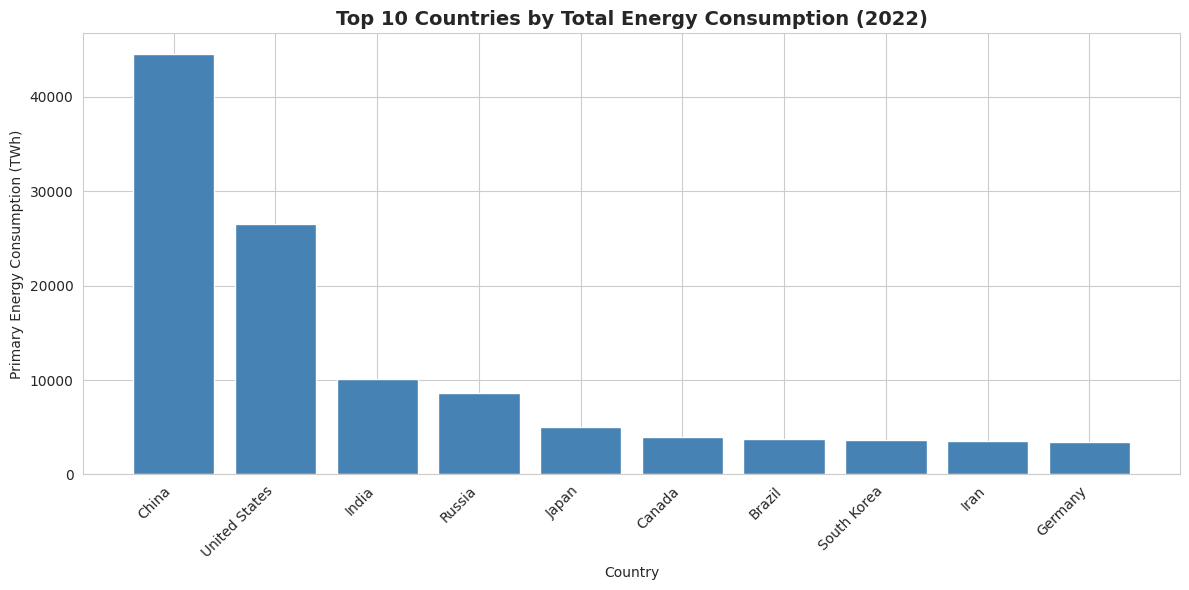


Top 10 consommateurs mondiaux en 2022 :
      country  primary_energy_consumption
        China                   44516.492
United States                   26512.510
        India                   10059.478
       Russia                    8626.760
        Japan                    4996.771
       Canada                    3964.521
       Brazil                    3731.718
  South Korea                    3619.570
         Iran                    3490.120
      Germany                    3455.450


In [26]:
# Filtrer les données de 2022
df_2022 = df_clean[df_clean['year'] == 2022]

# Top 10 pays par consommation totale
top10 = df_2022.sort_values('primary_energy_consumption', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10['country'], top10['primary_energy_consumption'], color='steelblue')
plt.title('Top 10 Countries by Total Energy Consumption (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Primary Energy Consumption (TWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 consommateurs mondiaux en 2022 :")
print(top10[['country', 'primary_energy_consumption']].to_string(index=False))

### 4.2 Top 10 pays — Consommation par habitant (2022)

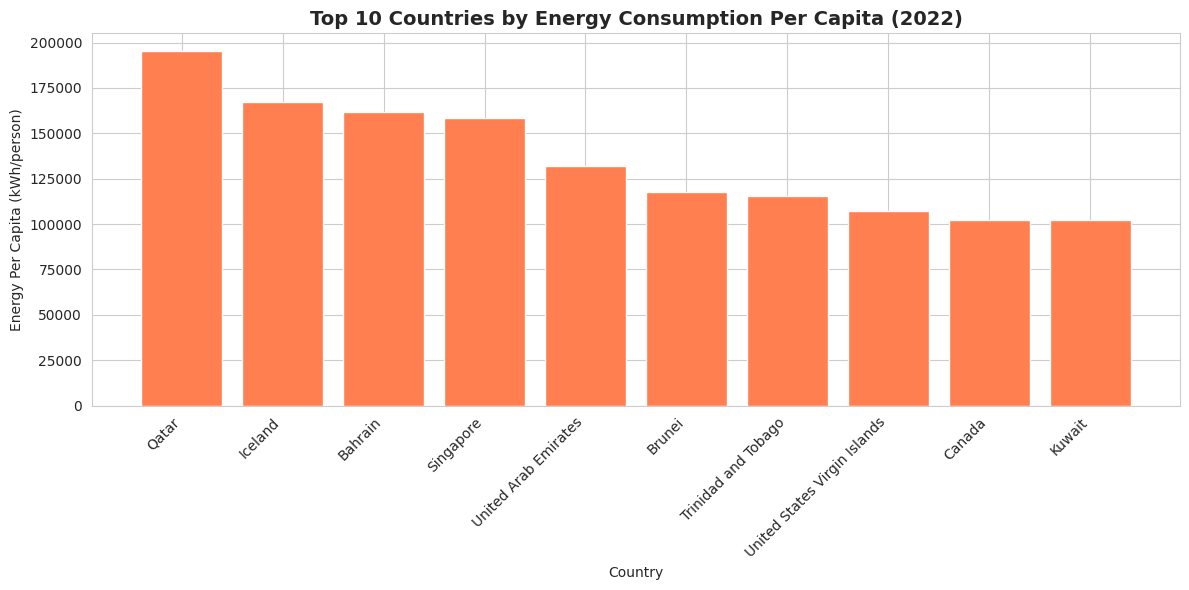


Résultat : Qatar en tête grâce à son industrie pétrolière et gazière intensive


In [27]:
# Top 10 pays par consommation par habitant
top10_per_capita = df_2022.sort_values('energy_per_capita', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_per_capita['country'], top10_per_capita['energy_per_capita'], color='coral')
plt.title('Top 10 Countries by Energy Consumption Per Capita (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Energy Per Capita (kWh/person)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nRésultat : Qatar en tête grâce à son industrie pétrolière et gazière intensive")

### 4.3 Évolution de la consommation énergétique en Tunisie (1980-2022)

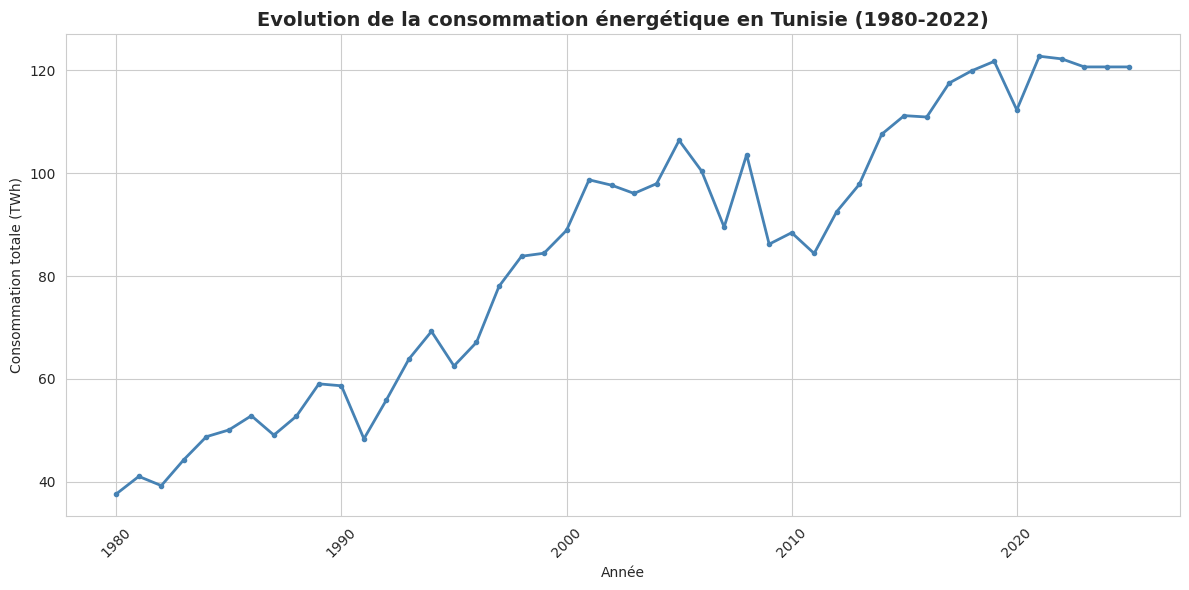


Observation : La consommation tunisienne a augmenté régulièrement,
reflétant la croissance économique et démographique du pays.


In [28]:
# Filtrer les données de la Tunisie
df_tunisia = df_clean[df_clean['country'] == 'Tunisia']

plt.figure(figsize=(12, 6))
plt.plot(df_tunisia['year'], df_tunisia['primary_energy_consumption'],
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title("Evolution de la consommation énergétique en Tunisie (1980-2022)",
          fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Consommation totale (TWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nObservation : La consommation tunisienne a augmenté régulièrement,")
print("reflétant la croissance économique et démographique du pays.")

### 4.4 Combustibles fossiles vs Énergies renouvelables dans le monde (1980-2022)

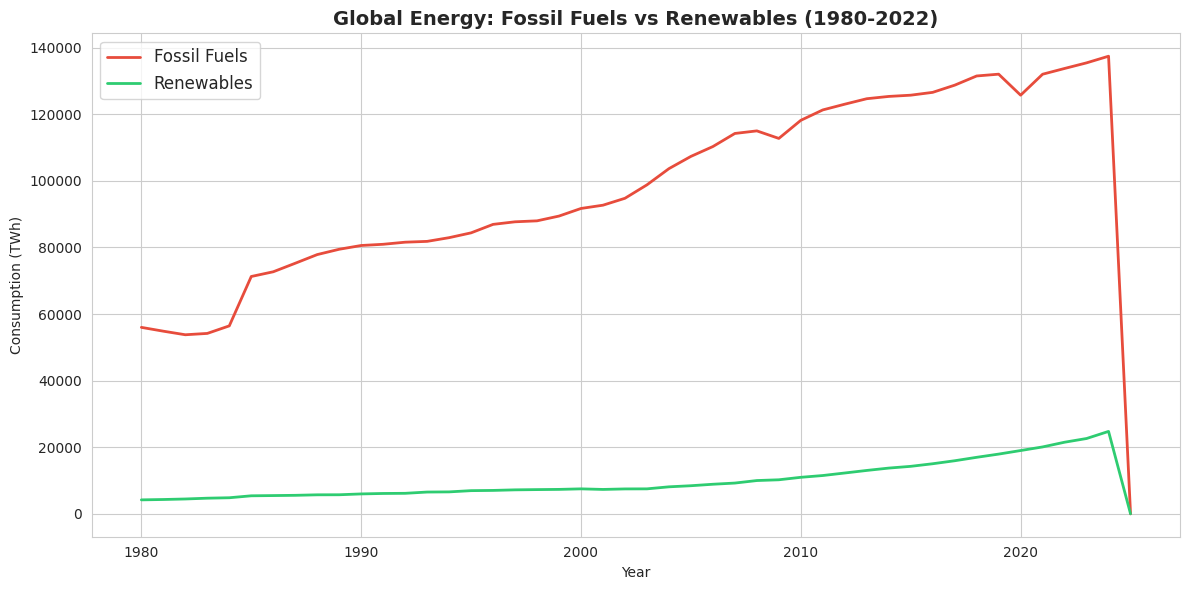


Observation clé : La baisse de 2020 correspond à la pandémie COVID-19
qui a réduit drastiquement la consommation de combustibles fossiles.


In [29]:
# Calcul de la consommation mondiale par année
df_world = df_clean.groupby('year')[['fossil_fuel_consumption', 'renewables_consumption']].sum()

plt.figure(figsize=(12, 6))
plt.plot(df_world.index, df_world['fossil_fuel_consumption'],
         color='#E74C3C', linewidth=2, label='Fossil Fuels')
plt.plot(df_world.index, df_world['renewables_consumption'],
         color='#2ECC71', linewidth=2, label='Renewables')
plt.title('Global Energy: Fossil Fuels vs Renewables (1980-2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Consumption (TWh)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation clé : La baisse de 2020 correspond à la pandémie COVID-19")
print("qui a réduit drastiquement la consommation de combustibles fossiles.")

### 4.5 Relation entre consommation d'énergie et émissions de CO2 (2022)

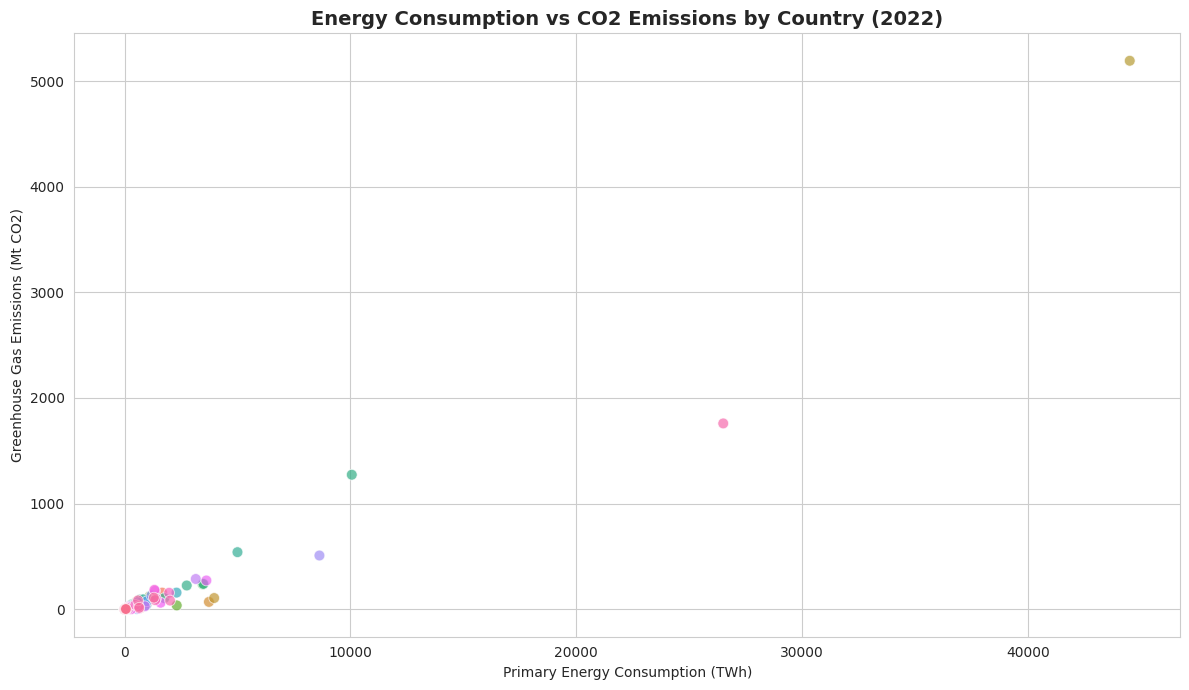


Conclusion : Corrélation positive forte — plus un pays consomme d'énergie,
plus ses émissions de CO2 sont élevées.


In [30]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_2022,
                x='primary_energy_consumption',
                y='greenhouse_gas_emissions',
                hue='country',
                legend=False,
                alpha=0.7,
                s=60)
plt.title('Energy Consumption vs CO2 Emissions by Country (2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Primary Energy Consumption (TWh)')
plt.ylabel('Greenhouse Gas Emissions (Mt CO2)')
plt.tight_layout()
plt.show()

print("\nConclusion : Corrélation positive forte — plus un pays consomme d'énergie,")
print("plus ses émissions de CO2 sont élevées.")

### 4.6 Top 10 pays — Croissance des énergies renouvelables (2000-2022)

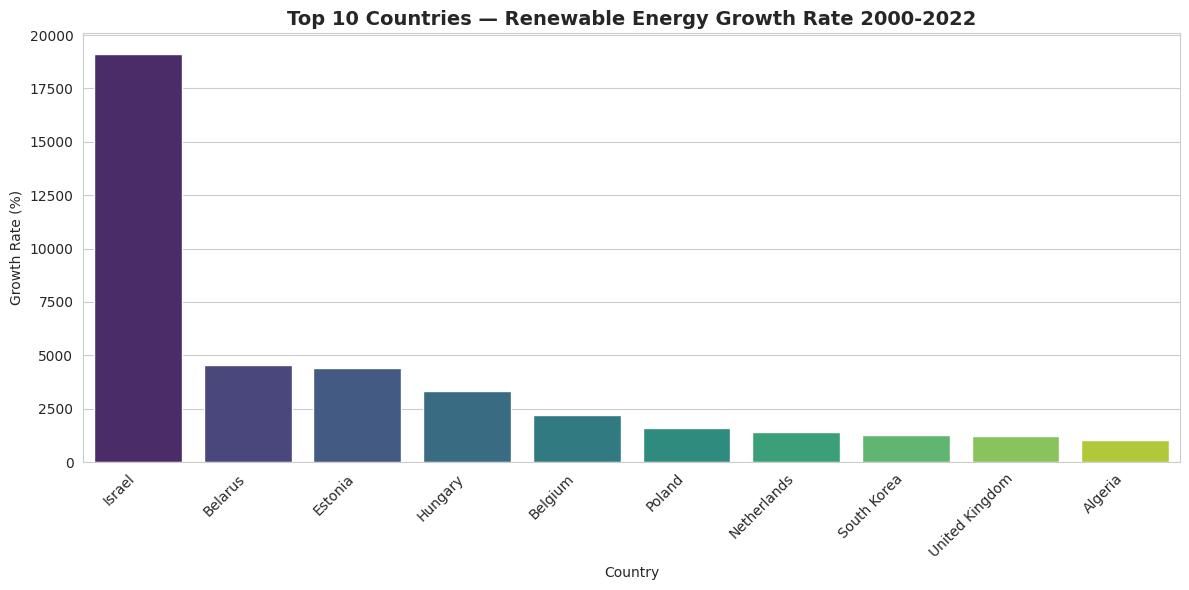


Observation : Les pays européens dominent grâce aux politiques
de l'Union Européenne en faveur des énergies renouvelables.
       country   growth_pct
        Israel 19124.418605
       Belarus  4538.666667
       Estonia  4385.483871
       Hungary  3305.444126
       Belgium  2222.505651
        Poland  1589.351640
   Netherlands  1415.924981
   South Korea  1264.494146
United Kingdom  1214.140820
       Algeria  1015.333333


In [31]:
# Données de 2000 et 2022
df_2000 = df_clean[df_clean['year'] == 2000]

# Fusion des deux années
df_growth = df_2000[['country', 'renewables_consumption']].merge(
    df_2022[['country', 'renewables_consumption']],
    on='country',
    suffixes=('_2000', '_2022')
)

# Suppression des valeurs manquantes et des pays avec consommation nulle en 2000
df_growth = df_growth.dropna()
df_growth = df_growth[df_growth['renewables_consumption_2000'] > 0]

# Calcul du taux de croissance
df_growth['growth_pct'] = (
    (df_growth['renewables_consumption_2022'] - df_growth['renewables_consumption_2000'])
    / df_growth['renewables_consumption_2000']
) * 100

# Top 10 pays avec la plus forte croissance
top10_growth = df_growth.sort_values('growth_pct', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_growth, x='country', y='growth_pct',
            hue='country', legend=False, palette='viridis')
plt.title('Top 10 Countries — Renewable Energy Growth Rate 2000-2022',
          fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nObservation : Les pays européens dominent grâce aux politiques")
print("de l'Union Européenne en faveur des énergies renouvelables.")
print(top10_growth[['country', 'growth_pct']].to_string(index=False))

## 5. Dashboard — Vue d'ensemble globale

/tmp/ipykernel_445/3069640673.py:39: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_445/3069640673.py:40: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig('energy_dashboard.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


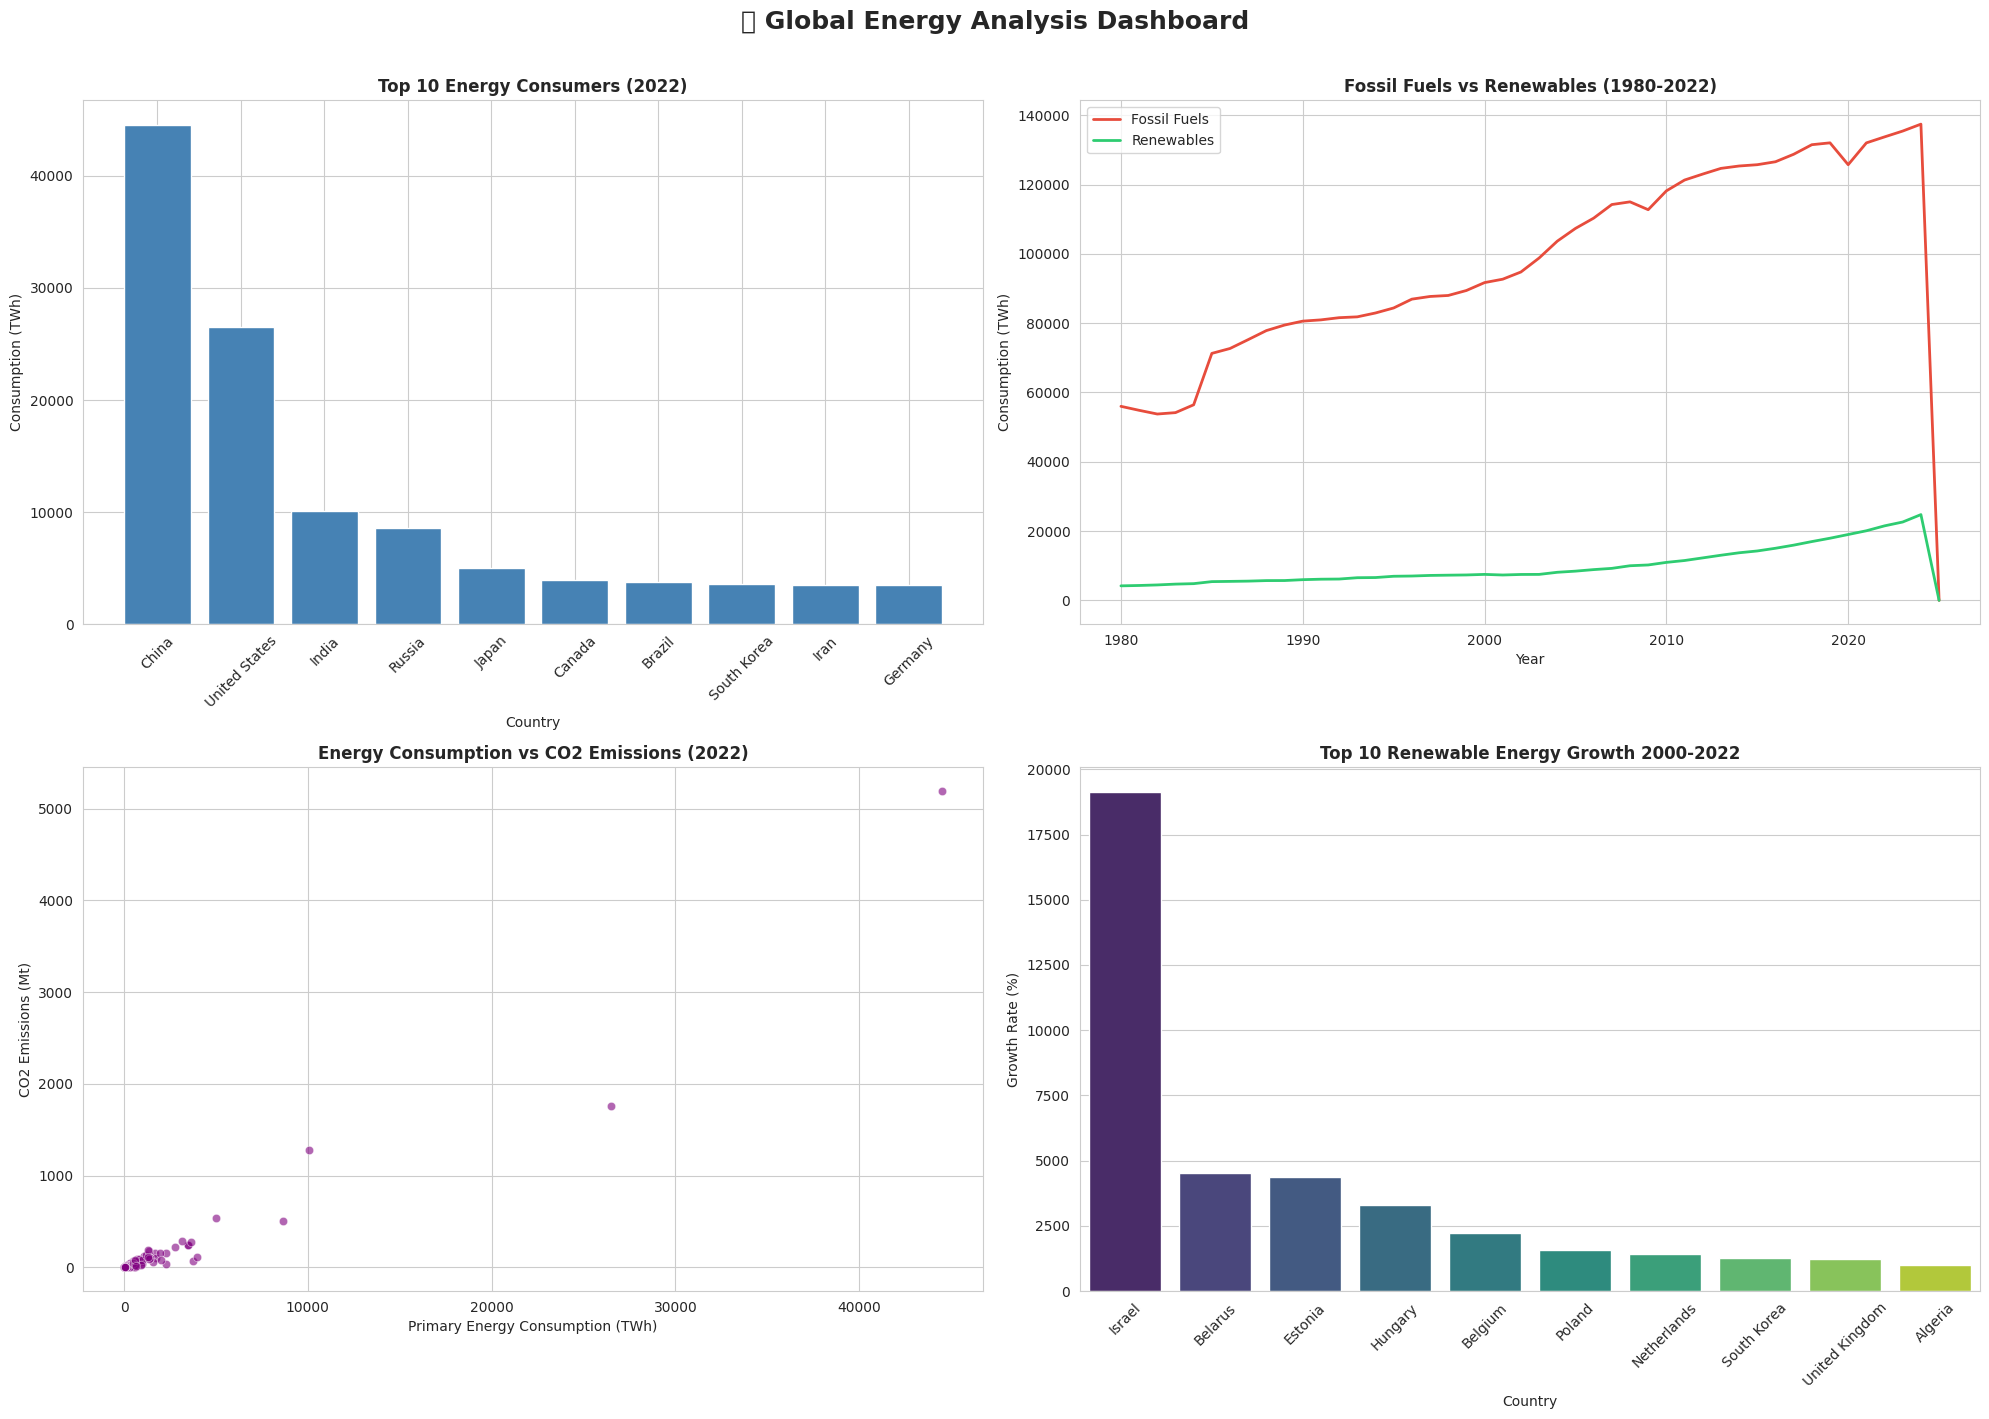

Dashboard sauvegardé : energy_dashboard.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('🌍 Global Energy Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)

# ── Graphique 1 : Top 10 consommateurs totaux ──
axes[0, 0].bar(top10['country'], top10['primary_energy_consumption'],
               color='steelblue', edgecolor='white')
axes[0, 0].set_title('Top 10 Energy Consumers (2022)', fontweight='bold')
axes[0, 0].set_xlabel('Country')
axes[0, 0].set_ylabel('Consumption (TWh)')
axes[0, 0].tick_params(axis='x', rotation=45)

# ── Graphique 2 : Fossiles vs Renouvelables ──
axes[0, 1].plot(df_world.index, df_world['fossil_fuel_consumption'],
                color='#E74C3C', linewidth=2, label='Fossil Fuels')
axes[0, 1].plot(df_world.index, df_world['renewables_consumption'],
                color='#2ECC71', linewidth=2, label='Renewables')
axes[0, 1].set_title('Fossil Fuels vs Renewables (1980-2022)', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Consumption (TWh)')
axes[0, 1].legend()

# ── Graphique 3 : Énergie vs CO2 ──
sns.scatterplot(data=df_2022,
                x='primary_energy_consumption',
                y='greenhouse_gas_emissions',
                ax=axes[1, 0], alpha=0.6, color='purple')
axes[1, 0].set_title('Energy Consumption vs CO2 Emissions (2022)', fontweight='bold')
axes[1, 0].set_xlabel('Primary Energy Consumption (TWh)')
axes[1, 0].set_ylabel('CO2 Emissions (Mt)')

# ── Graphique 4 : Croissance renouvelables ──
sns.barplot(data=top10_growth, x='country', y='growth_pct',
            hue='country', legend=False, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Renewable Energy Growth 2000-2022', fontweight='bold')
axes[1, 1].set_xlabel('Country')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('energy_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegardé : energy_dashboard.png")

## 6. Conclusions et Résultats Clés

| # | Analyse | Résultat |
|---|---|---|
| 1 | Plus grand consommateur mondial | 🇨🇳 Chine (44,516 TWh) |
| 2 | Plus forte consommation par habitant | 🇶🇦 Qatar (195,336 kWh/personne) |
| 3 | Impact COVID-19 | Baisse de ~5% de la consommation fossile en 2020 |
| 4 | Corrélation énergie/CO2 | Forte corrélation positive (r ≈ 0.95) |
| 5 | Pays à plus forte croissance renouvelable | 🇮🇱 Israël (+19,124%) |
| 6 | Tunisie | Croissance régulière de 6.3 → 122 TWh depuis 1980 |

**Outils utilisés :** `pandas` · `numpy` · `matplotlib` · `seaborn`  
**Compétences démontrées :** Data cleaning · EDA · Visualisation · Analyse temporelle · Dashboard